{'科幻': 34, '动作': 53, '冒险': 50, '恐怖': 13, '悬疑': 19, '惊悚': 51, '喜剧': 47, '家庭': 32, '奇幻': 42, '爱情': 49, '动画': 56, '剧情': 172, '犯罪': 38, '西部': 4, '历史': 17, '纪录': 24, '音乐': 20, '战争': 18, '电视电影': 6}


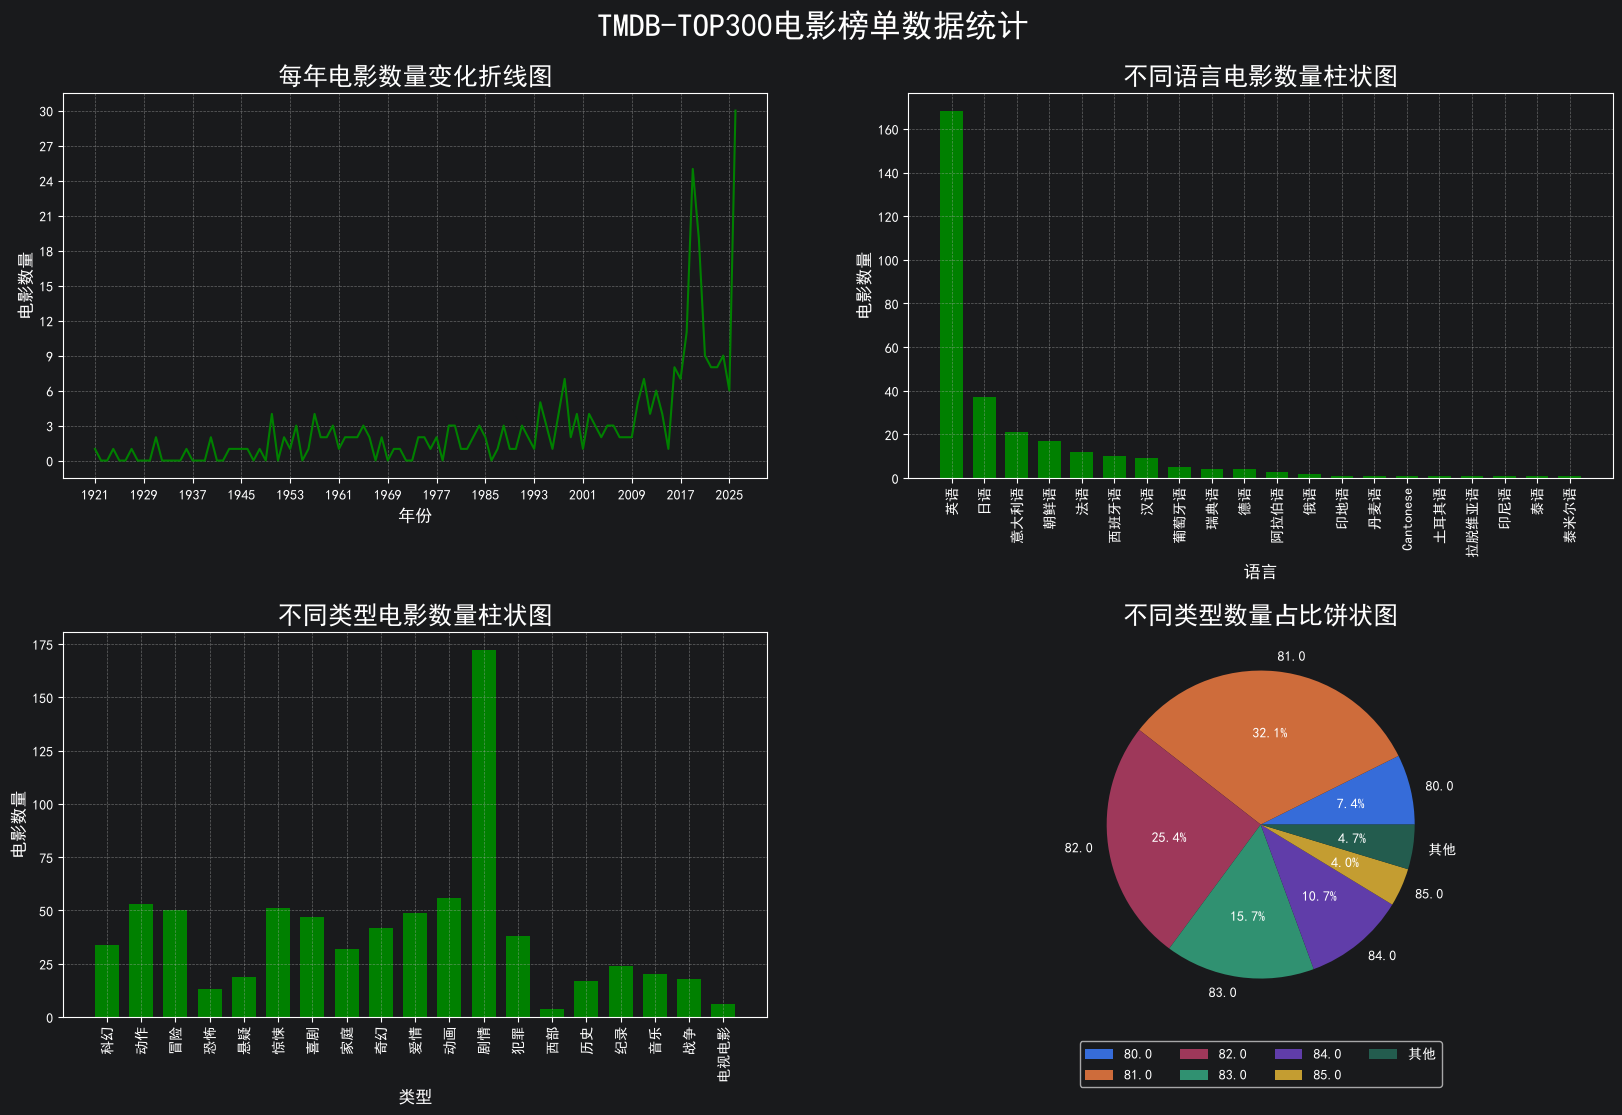

In [1]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core import sorting

#展示中文
plt.rcParams['font.sans-serif']=['SimHei']
# 创建子图
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
fig.suptitle('TMDB-TOP300电影榜单数据统计',fontsize=23,x=0.5,y=0.95)#添加画布标-x=0.5:X轴位置；y=0.95:y轴位置
fig.subplots_adjust(hspace=0.4,wspace=0.2)#调整子图间距，hspace:控制垂直间距，wspace:控制水平间距
# 获取子图
axes1:Axes=axes[0][0]
axes2:Axes=axes[0][1]
axes3:Axes=axes[1][0]
axes4:Axes=axes[1][1]
#加载数据

data=pd.read_csv('csv_data/movie.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})#Int64允许缺失值，int64不允许。
# .
# 1.1 缺失值、异常值处理(本来年份没有缺失值，只是练习)
data.isnull().sum()
data['年份']=data['年份'].fillna(data['上映时间'].str[:4])
#1.2分组统计
year_count=data.groupby('年份')['年份'].count()

#1.3组装数据
#`1.3.1 x轴数据
min_year=year_count.index.min()
max_year=year_count.index.max()
x=[i for i  in range(min_year,max_year+1)]
#1.3.2 y轴数据
y=[int(year_count.get(i,0)) for i in x]

#1.4绘制折线图
axes1.plot(x,y,color='green')
axes1.set_title('每年电影数量变化折线图',fontsize=18)
axes1.set_xlabel('年份',fontsize=12)
axes1.set_ylabel('电影数量',fontsize=12)
axes1.set_xticks(x[::8])
y_ticks=[i for i in range(0,31,3)]
axes1.set_yticks(y_ticks)
axes1.grid(linestyle='--',alpha=0.5)
#需求2：统计不同语言对应的电影数量
# #2.1获取不同语言对应的电影数量
language_count=data.groupby('语言')['语言'].count().sort_values(ascending=False)

x_language=language_count.index.tolist()
y_language_count=language_count.values.tolist()
#2.2绘制柱状图
axes2.bar(x_language,y_language_count,color='green',width=0.7)
axes2.set_title('不同语言电影数量柱状图',fontsize=18)#添加子图标题
axes2.set_xlabel('语言',fontsize=12)#添加X轴标签
axes2.set_ylabel('电影数量',fontsize=12)#添加Y轴标签
axes2.grid(linestyle="--",alpha=0.5)#添加网格线
axes2.tick_params(axis='x',rotation=90)#旋转x轴标签
#需求3：统计对比不同类型的电影数量（柱状图）
type_count={}
for types in data['类型'].str.split(','):#剧情、犯罪
    for type in types:#剧情
        if type in type_count:
            type_count[type]+=1
        else:
            type_count[type] = 1
print(type_count)
x_types=list(type_count.keys())
y_values=list(type_count.values())

#3.2绘制柱状图
axes3.bar(x_types,y_values,color='green',width=0.7)
axes3.set_title('不同类型电影数量柱状图',fontsize=18)#添加子图标题
axes3.set_xlabel('类型',fontsize=12)#添加X轴标签
axes3.set_ylabel('电影数量',fontsize=12)#添加Y轴标签
axes3.grid(linestyle="--",alpha=0.5)#添加网格线
axes3.tick_params(axis='x',rotation=90)#旋转x轴标签
#4.需求4：统计不同评分电影的占比
#4.1获取不同评分对应的电影数量
score_count=data.groupby('评分')['评分'].count()
total=score_count.sum()
large_scores=score_count.loc[score_count>=total*0.02]#大数据，比例>=2%
small_scores=score_count.loc[score_count<total*0.02]#小数据，比例<2%
if small_scores.shape[0]>0:
    large_scores['其他']=small_scores.sum()

#合并小数据（比例小于2%）
scores=large_scores.index.tolist()#评分列表
score_values=large_scores.values.tolist()#数量列表
#4.2绘制饼状图
axes4.pie(score_values,labels=scores,autopct='%1.1f%%',startangle=0)#startangle 起始角度
axes4.set_title('不同类型数量占比饼状图',fontsize=18)
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.2))
#5.保存图片
plt.savefig('csv_data/TMDB-TOP300.png')
plt.show()#显示画布

